<a href="https://colab.research.google.com/github/PoptropicaSahil/Fontify/blob/main/Fontifyv3_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# everything is installed already
# !pip install torch torchvision pillow matplotlib scikit-learn numpy

# need for svg processing
!pip install cairosvg --quiet

In [ ]:
import zipfile

import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# import torchvision.transforms as transforms
from torchvision import transforms

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pickle
from cairosvg import svg2png
from io import BytesIO

In [ ]:
# unzip given files
zip_folder = '/content/drive/MyDrive/Fontify'

# Destination folder for extracted files
extract_folder = 'figma-salu-v2'

os.makedirs(extract_folder, exist_ok=True)

for filename in os.listdir(zip_folder):
    if filename.endswith('.zip'):
        zip_path = os.path.join(zip_folder, filename)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_folder)

print("All zip files extracted to", extract_folder)


All zip files extracted to figma-salu-v2


In [ ]:
# deleted "----.svg"

In [ ]:
# rename the files starting with a leading "-"
# only removing the fist character is sufficient

extract_folder = 'figma-salu-v2'

for filename in os.listdir(extract_folder):
    if filename.startswith('-'):
        old_path = os.path.join(extract_folder, filename)
        new_filename = filename[1:]  # Remove the first character
        new_path = os.path.join(extract_folder, new_filename)
        os.rename(old_path, new_path)
        print(f"Renamed: {filename} -> {new_filename}")

print("File renaming complete.")

Renamed: -Zither-India.svg -> Zither-India.svg
Renamed: -SF-Georgian.svg -> SF-Georgian.svg
Renamed: -SF-Georgian-Rounded.svg -> SF-Georgian-Rounded.svg
Renamed: ----.svg -> ---.svg
Renamed: -SF-Compact.svg -> SF-Compact.svg
Renamed: -Helvetica-LT-MM.svg -> Helvetica-LT-MM.svg
Renamed: -SF-Compact-Rounded.svg -> SF-Compact-Rounded.svg
Renamed: -SF-Hebrew.svg -> SF-Hebrew.svg
Renamed: -SF-Armenian-Rounded.svg -> SF-Armenian-Rounded.svg
Renamed: -Times-LT-MM.svg -> Times-LT-MM.svg
Renamed: -CJK-Symbols-Fallback-MO.svg -> CJK-Symbols-Fallback-MO.svg
Renamed: -----.svg -> ----.svg
Renamed: -SF-Soft-Numeric.svg -> SF-Soft-Numeric.svg
Renamed: -SF-Arabic.svg -> SF-Arabic.svg
Renamed: -SF-Hebrew-Rounded.svg -> SF-Hebrew-Rounded.svg
Renamed: -ThonburiUIWatch.svg -> ThonburiUIWatch.svg
Renamed: -ThonburiUI.svg -> ThonburiUI.svg
Renamed: -SF-NS-Mono.svg -> SF-NS-Mono.svg
Renamed: -Aqua-Kana.svg -> Aqua-Kana.svg
Renamed: -CJK-Symbols-Fallback-Watch-HK.svg -> CJK-Symbols-Fallback-Watch-HK.svg
Rena

In [ ]:
class SVGFontDataset(Dataset):
    def __init__(self, svg_folder, image_size=128, transform=None):
        self.svg_folder = svg_folder
        self.image_size = image_size
        self.transform = transform

        # Get all SVG files
        self.svg_files = [f for f in os.listdir(svg_folder) if f.endswith('.svg')]
        self.svg_files.sort()  # Ensure consistent ordering

    def __len__(self):
        return len(self.svg_files)

    def svg_to_image(self, svg_path):
        """
        Convert SVG to PIL Image
        The input svg images are 640*640, we resize them to be 320*320
        """
        try:
            # Read SVG file
            with open(svg_path, 'rb') as f:
                svg_data = f.read()

            # Convert SVG to PNG
            png_data = svg2png(
                bytestring=svg_data,
                output_width=self.image_size,
                output_height=self.image_size,
                background_color='white'
            )

            # Convert to PIL Image
            image = Image.open(BytesIO(png_data))
            # Convert to grayscale
            image = image.convert('L')

            return image
        except Exception as e:
            print(f"Error processing {svg_path}: {e}")
            # Return a blank image as fallback
            return Image.new('L', (self.image_size, self.image_size), 255)

    def __getitem__(self, idx):
        svg_path = os.path.join(self.svg_folder, self.svg_files[idx])
        image = self.svg_to_image(svg_path)

        # Convert to tensor
        image_tensor = transforms.ToTensor()(image)

        # Apply transforms if any
        # if self.transform:
        #     image_tensor = self.transform(image_tensor)

        return image_tensor, self.svg_files[idx]


In [ ]:
class FontAutoencoder(nn.Module):
    def __init__(self, input_size=192, embedding_dim=256):
        # super(FontAutoencoder, self).__init__()
        super().__init__()

        self.input_size = input_size
        self.embedding_dim = embedding_dim

        # Calculate output size after conv layers - 192 -> 12
        conv_output_size = input_size // 16  # 192 -> 12
        self.conv_output_dim = 256 * conv_output_size * conv_output_size

        # Enhanced Encoder with residual blocks and attention
        self.encoder = nn.Sequential(
            # Initial conv
            nn.Conv2d(1, 32, kernel_size=7, stride=1, padding=3),  # Larger initial kernel
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # Block 1: 192 -> 96 with residual
            self._make_residual_block(32, 64, stride=2),

            # Block 2: 96 -> 48 with residual
            self._make_residual_block(64, 128, stride=2),

            # Block 3: 48 -> 24 with residual
            self._make_residual_block(128, 192, stride=2),

            # Block 4: 24 -> 12 with residual
            self._make_residual_block(192, 256, stride=2),

            # Global Average Pooling for spatial attention
            nn.AdaptiveAvgPool2d((6, 6)),  # Fixed spatial size

            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            nn.Linear(512, embedding_dim)
        )

        # Enhanced Decoder with skip connections
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),

            nn.Linear(1024, 256 * 6 * 6),
            nn.ReLU(inplace=True),

            nn.Unflatten(1, (256, 6, 6)),

            # Upsample to 12x12
            nn.Upsample(size=(12, 12), mode='bilinear', align_corners=False),

            # 12 -> 24 with residual decoder block
            self._make_decoder_residual_block(256, 192),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            # 24 -> 48 with residual decoder block
            self._make_decoder_residual_block(192, 128),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            # 48 -> 96 with residual decoder block
            self._make_decoder_residual_block(128, 64),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            # 96 -> 192 with residual decoder block
            self._make_decoder_residual_block(64, 32),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # This gets us to 192x192

            # Final conv
            nn.Conv2d(32, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=7, stride=1, padding=3),  # Larger final kernel
            nn.Sigmoid()
        )

    def _make_residual_block(self, in_channels, out_channels, stride=1):
        """Create a residual block with skip connection"""
        return ResidualBlock(in_channels, out_channels, stride)

    def _make_decoder_residual_block(self, in_channels, out_channels):
        """Create a decoder residual block"""
        return DecoderResidualBlock(in_channels, out_channels)

    def forward(self, x):
        embedding = self.encoder(x)
        # Enhanced normalization with learnable scaling
        embedding = F.normalize(embedding, p=2, dim=1) * 10.0  # Scale for better gradients
        reconstruction = self.decoder(embedding)
        return embedding, reconstruction

    def encode(self, x):
        embedding = self.encoder(x)
        return F.normalize(embedding, p=2, dim=1) * 10.0

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip connection
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += residual
        out = F.relu(out)

        return out

class DecoderResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Skip connection
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        out += residual
        out = F.relu(out)

        return out

In [ ]:
def create_augmentation_transforms():
    """Simple, stable augmentation"""
    return transforms.Compose([
        transforms.RandomRotation(degrees=5),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05)
        ),
        # Clamp to valid range
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])

def simple_contrastive_loss(embeddings1, embeddings2, temperature=0.2):
    """Simplified contrastive loss with proper normalization"""
    batch_size = embeddings1.size(0)

    # Embeddings are already normalized in forward pass
    # Compute similarities
    sim_matrix = torch.matmul(embeddings1, embeddings2.T) / temperature

    # Create positive labels (diagonal entries)
    labels = torch.arange(batch_size, device=embeddings1.device)

    # Symmetric loss
    loss_12 = F.cross_entropy(sim_matrix, labels)
    loss_21 = F.cross_entropy(sim_matrix.T, labels)

    return (loss_12 + loss_21) / 2


def enhanced_contrastive_loss(embeddings1, embeddings2, temperature=0.15):
    """Enhanced contrastive loss with better numerical stability"""
    batch_size = embeddings1.size(0)

    # Normalize embeddings (they're already scaled by 10.0)
    embeddings1 = F.normalize(embeddings1, p=2, dim=1)
    embeddings2 = F.normalize(embeddings2, p=2, dim=1)

    # Compute similarities with numerical stability
    sim_matrix = torch.matmul(embeddings1, embeddings2.T) / temperature

    # Subtract max for numerical stability
    sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True)[0].detach()

    labels = torch.arange(batch_size, device=embeddings1.device)

    # Symmetric loss with label smoothing
    loss_12 = F.cross_entropy(sim_matrix, labels, label_smoothing=0.1)
    loss_21 = F.cross_entropy(sim_matrix.T, labels, label_smoothing=0.1)

    return (loss_12 + loss_21) / 2


In [ ]:
class SimpleFontTrainer:
    def __init__(self, model, device):
        self.model = model.to(device)
        self.device = device
        self.optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.7)
        self.recon_criterion = nn.MSELoss()
        self.train_losses = []

    def train_epoch(self, dataloader, use_contrastive=True):
        self.model.train()
        total_loss = 0
        total_recon_loss = 0
        total_contrast_loss = 0

        for batch_idx, (images, filenames) in enumerate(dataloader):
            images = images.to(self.device)
            batch_size = images.size(0)

            self.optimizer.zero_grad()

            if use_contrastive and batch_size > 1:

                # Apply augmentation to create pairs from same images
                augment_transform = create_augmentation_transforms()

                # Create augmented version of the batch
                images_aug = torch.stack([augment_transform(img) for img in images])

                # Forward pass on original and augmented
                emb1, recon1 = self.model(images)
                emb2, recon2 = self.model(images_aug)

                # Reconstruction loss (only on original images)
                recon_loss = self.recon_criterion(recon1, images)

                # Simple contrastive loss between original and augmented embeddings
                contrast_loss = enhanced_contrastive_loss(emb1, emb2)

                # Check for NaN
                if torch.isnan(contrast_loss) or torch.isinf(contrast_loss):
                    contrast_loss = torch.tensor(0.0, device=self.device)

                # Combined loss with smaller contrastive weight
                total_loss_batch = recon_loss + 0.1 * contrast_loss

                total_contrast_loss += contrast_loss.item()

                # if mid > 0:
                #     images1 = images[:mid]
                #     images2 = images[mid:2*mid]  # Take equal sized batches

                #     # Forward pass
                #     emb1, recon1 = self.model(images1)
                #     emb2, recon2 = self.model(images2)

                #     # Reconstruction loss
                #     recon_loss = (self.recon_criterion(recon1, images1) +
                #                  self.recon_criterion(recon2, images2)) / 2

                #     # Simple contrastive loss
                #     contrast_loss = enhanced_contrastive_loss(emb1, emb2)

                #     # Check for NaN
                #     if torch.isnan(contrast_loss) or torch.isinf(contrast_loss):
                #         contrast_loss = torch.tensor(0.0, device=self.device)

                #     # Combined loss with smaller contrastive weight
                #     total_loss_batch = recon_loss + 0.1 * contrast_loss

                #     total_contrast_loss += contrast_loss.item()
                # else:
                #     # Fallback to reconstruction only
                #     emb, recon = self.model(images)
                #     total_loss_batch = self.recon_criterion(recon, images)
                #     recon_loss = total_loss_batch
                #     contrast_loss = torch.tensor(0.0)
            else:
                # Reconstruction only
                emb, recon = self.model(images)
                total_loss_batch = self.recon_criterion(recon, images)
                recon_loss = total_loss_batch
                contrast_loss = torch.tensor(0.0)

            # Check for NaN in total loss
            if torch.isnan(total_loss_batch) or torch.isinf(total_loss_batch):
                print(f"Warning: NaN/Inf loss at batch {batch_idx}, skipping...")
                continue

            total_loss_batch.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.optimizer.step()

            total_loss += total_loss_batch.item()
            total_recon_loss += recon_loss.item()

            if batch_idx % 50 == 0:
                print(f'Batch {batch_idx}/{len(dataloader)}, '
                      f'Total: {total_loss_batch.item():.6f}, '
                      f'Recon: {recon_loss.item():.6f}, '
                      f'Contrast: {contrast_loss.item():.6f}')

        avg_loss = total_loss / len(dataloader)
        avg_recon = total_recon_loss / len(dataloader)
        avg_contrast = total_contrast_loss / len(dataloader) if total_contrast_loss > 0 else 0

        return avg_loss, avg_recon, avg_contrast

    def train(self, dataloader, epochs=200, use_contrastive=True):
        print(f"Training {'contrastive ' if use_contrastive else ''}autoencoder for {epochs} epochs...")

        for epoch in range(epochs):
            avg_loss, avg_recon, avg_contrast = self.train_epoch(dataloader, use_contrastive)

            self.scheduler.step()
            self.train_losses.append(avg_loss)

            print(f'Epoch {epoch+1}/{epochs}:')
            print(f'  Total Loss: {avg_loss:.6f}')
            print(f'  Reconstruction: {avg_recon:.6f}')
            if use_contrastive:
                print(f'  Contrastive: {avg_contrast:.6f}')
            print(f'  LR: {self.optimizer.param_groups[0]["lr"]:.6f}')
            print('-' * 40)

            # Save checkpoint every 25 epochs
            if (epoch + 1) % 25 == 0:
                self.save_checkpoint(f'font_model_epoch_{epoch+1}.pth')

        # Save final model
        self.save_checkpoint('font_model_final.pth')
        print("Training completed!")

    def save_checkpoint(self, filename):
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'train_losses': self.train_losses
        }, filename)
        print(f"Saved: {filename}")

In [ ]:
def create_contrastive_dataset(base_dataset, augment_prob=0.7):
    """Create augmented pairs from base dataset"""
    augment_transform = create_augmentation_transforms()

    augmented_data = []

    for i in range(len(base_dataset)):
        image, filename, idx = base_dataset[i]

        # Original image
        augmented_data.append((image, filename, idx))

        # Augmented version with some probability
        if np.random.random() < augment_prob:
            aug_image = augment_transform(image)
            augmented_data.append((aug_image, filename, idx))

    return augmented_data

def extract_embeddings(model, dataloader, device):
    """Extract embeddings for all fonts"""
    model.eval()
    all_embeddings = []
    all_filenames = []

    with torch.no_grad():
        for images, filenames in dataloader:
            images = images.to(device)
            embeddings = model.encode(images)

            all_embeddings.append(embeddings.cpu().numpy())
            all_filenames.extend(filenames)

    return np.vstack(all_embeddings), all_filenames

def visualize_reconstructions(model, dataloader, device, num_samples=6):
    """Visualize original vs reconstructed images"""
    model.eval()

    with torch.no_grad():
        images, filenames = next(iter(dataloader))
        images = images[:num_samples].to(device)

        embeddings, reconstructions = model(images)

        fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

        for i in range(num_samples):
            # Original
            axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[0, i].set_title(f'Original\n{filenames[i][:15]}...', fontsize=8)
            axes[0, i].axis('off')

            # Reconstruction
            axes[1, i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
            axes[1, i].set_title('Reconstructed', fontsize=8)
            axes[1, i].axis('off')

        plt.tight_layout()
        plt.savefig('reconstruction_results.png', dpi=150, bbox_inches='tight')
        plt.show()

def analyze_embeddings(embeddings, filenames, top_k=5):
    """Analyze embedding similarities"""
    print("\nFont Similarity Analysis:")
    print("=" * 50)

    similarity_matrix = cosine_similarity(embeddings)

    for i, filename in enumerate(filenames[:10]):
        similarities = similarity_matrix[i]
        top_indices = np.argsort(similarities)[-top_k-1:-1][::-1]

        print(f"\nFont: {filename}")
        print("Most similar:")
        for j, idx in enumerate(top_indices):
            if idx != i:
                print(f"  {j+1}. {filenames[idx]} ({similarities[idx]:.3f})")



def plot_training_progress(trainer):
    """Plot training losses"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Total loss
    axes[0].plot(trainer.train_losses)
    axes[0].set_title('Total Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True)

    # Reconstruction loss
    axes[1].plot(trainer.recon_losses, color='orange')
    axes[1].set_title('Reconstruction Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE Loss')
    axes[1].grid(True)

    # Contrastive loss
    axes[2].plot(trainer.contrastive_losses, color='green')
    axes[2].set_title('Contrastive Loss')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('InfoNCE Loss')
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig('training_progress.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
def main():
    # Configuration
    SVG_FOLDER =  "/content/figma-salu-v2"  # UPDATE THIS
    IMAGE_SIZE = 192
    EMBEDDING_DIM = 256
    BATCH_SIZE = 24  # Increased from 4
    EPOCHS = 30   # Reduced from 250
    USE_CONTRASTIVE = True  # Set to False for pure autoencoder

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    if torch.cuda.is_available():
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"GPU Memory: {gpu_memory:.1f} GB")

    # Create dataset
    print("Loading dataset...")
    base_dataset = SVGFontDataset(SVG_FOLDER, IMAGE_SIZE, transform=None)

    print(f"Found {len(base_dataset)} SVG files")

    # Create dataloader
    dataloader = DataLoader(
        base_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        drop_last=True  # Important for contrastive learning
    )

    # Initialize model
    model = FontAutoencoder(input_size=IMAGE_SIZE, embedding_dim=EMBEDDING_DIM)

    # Initialize weights properly
    def init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    model.apply(init_weights)

    trainer = SimpleFontTrainer(model, device)

    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Train model
    trainer.train(dataloader, epochs=EPOCHS, use_contrastive=USE_CONTRASTIVE)

    # Create clean dataset for embedding extraction (no augmentation)
    clean_dataset = SVGFontDataset(SVG_FOLDER, IMAGE_SIZE, transform=None)
    clean_dataloader = DataLoader(clean_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Extract embeddings
    print("\nExtracting embeddings...")
    embeddings, filenames = extract_embeddings(model, clean_dataloader, device)

    # Save embeddings
    embedding_data = {
        'embeddings': embeddings,
        'filenames': filenames,
        'metadata': {
            'embedding_dim': EMBEDDING_DIM,
            'image_size': IMAGE_SIZE,
            'num_fonts': len(filenames),
            'contrastive': USE_CONTRASTIVE
        }
    }

    with open('font_embeddings.pkl', 'wb') as f:
        pickle.dump(embedding_data, f)

    print(f"Embeddings saved! Shape: {embeddings.shape}")

    # Visualize results
    visualize_reconstructions(model, clean_dataloader, device)
    analyze_embeddings(embeddings, filenames)

    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(trainer.train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.savefig('training_loss.png')
    plt.show()

    return model, embeddings, filenames

Using device: cuda
GPU Memory: 15.8 GB
Loading dataset...
Found 2143 SVG files
Model parameters: 23,530,977
Training contrastive autoencoder for 30 epochs...
Batch 0/89, Total: 0.525497, Recon: 0.216060, Contrast: 3.094374
Batch 50/89, Total: 0.158025, Recon: 0.065627, Contrast: 0.923975
Epoch 1/30:
  Total Loss: 0.181433
  Reconstruction: 0.060843
  Contrastive: 1.205895
  LR: 0.001000
----------------------------------------
Batch 0/89, Total: 0.142108, Recon: 0.050734, Contrast: 0.913739
Batch 50/89, Total: 0.146225, Recon: 0.052020, Contrast: 0.942052
Epoch 2/30:
  Total Loss: 0.137517
  Reconstruction: 0.046302
  Contrastive: 0.912148
  LR: 0.001000
----------------------------------------
Batch 0/89, Total: 0.137128, Recon: 0.038698, Contrast: 0.984300
Batch 50/89, Total: 0.129823, Recon: 0.040933, Contrast: 0.888905
Epoch 3/30:
  Total Loss: 0.129689
  Reconstruction: 0.043402
  Contrastive: 0.862864
  LR: 0.001000
----------------------------------------
Batch 0/89, Total: 0.12

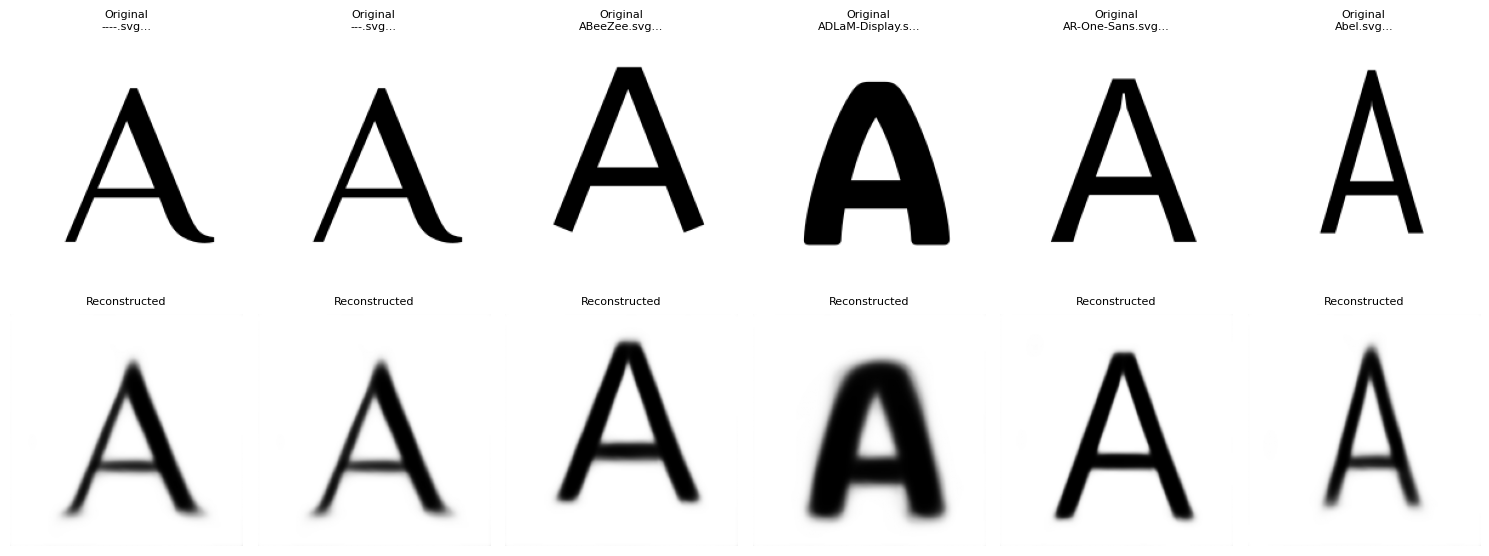


Font Similarity Analysis:

Font: ----.svg
Most similar:
  2. ZCOOL-XiaoWei.svg (1.000)
  3. Philosopher.svg (0.903)
  4. Malayalam-MN.svg (0.895)
  5. Belleza.svg (0.872)

Font: ---.svg
Most similar:
  1. ----.svg (1.000)
  2. ZCOOL-XiaoWei.svg (1.000)
  3. Philosopher.svg (0.903)
  4. Malayalam-MN.svg (0.895)
  5. Belleza.svg (0.872)

Font: ABeeZee.svg
Most similar:
  1. Numans.svg (0.963)
  2. Varela-Round.svg (0.905)
  3. Hei.svg (0.864)
  4. Archivo.svg (0.851)
  5. Heebo.svg (0.801)

Font: ADLaM-Display.svg
Most similar:
  1. Ramabhadra.svg (0.826)
  2. Tilt-Warp.svg (0.808)
  3. Bagel-Fat-One.svg (0.771)
  4. PoetsenOne.svg (0.762)
  5. Paytone-One.svg (0.754)

Font: AR-One-Sans.svg
Most similar:
  1. IBM-Plex-Sans-Hebrew.svg (0.892)
  2. Anuphan.svg (0.892)
  3. IBM-Plex-Sans.svg (0.892)
  4. SF-NS-Rounded.svg (0.892)
  5. Oxygen.svg (0.874)

Font: Abel.svg
Most similar:
  1. Unica-One.svg (0.878)
  2. Truculenta.svg (0.843)
  3. Smooch-Sans.svg (0.833)
  4. Marvel.svg (0.821)


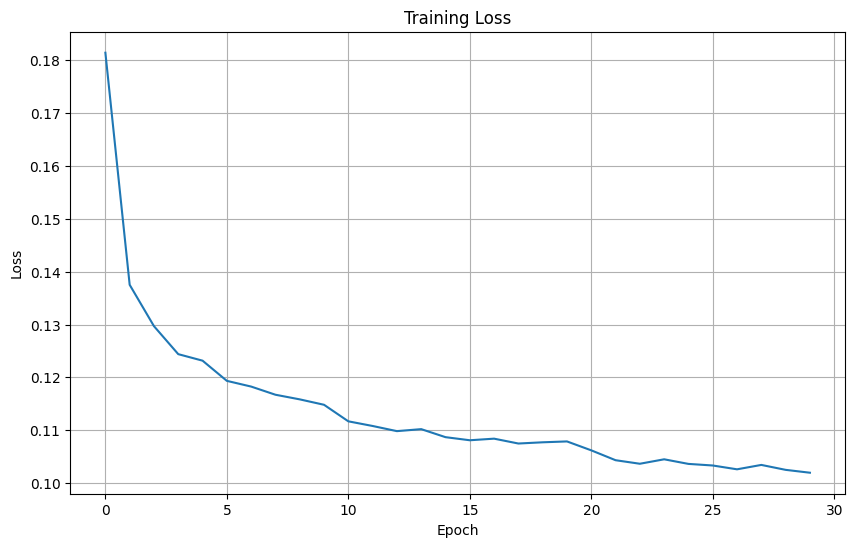

In [ ]:
model, embeddings, filenames = main()

In [ ]:
1

1

In [ ]:
# model, embeddings, filenames = Out[12]

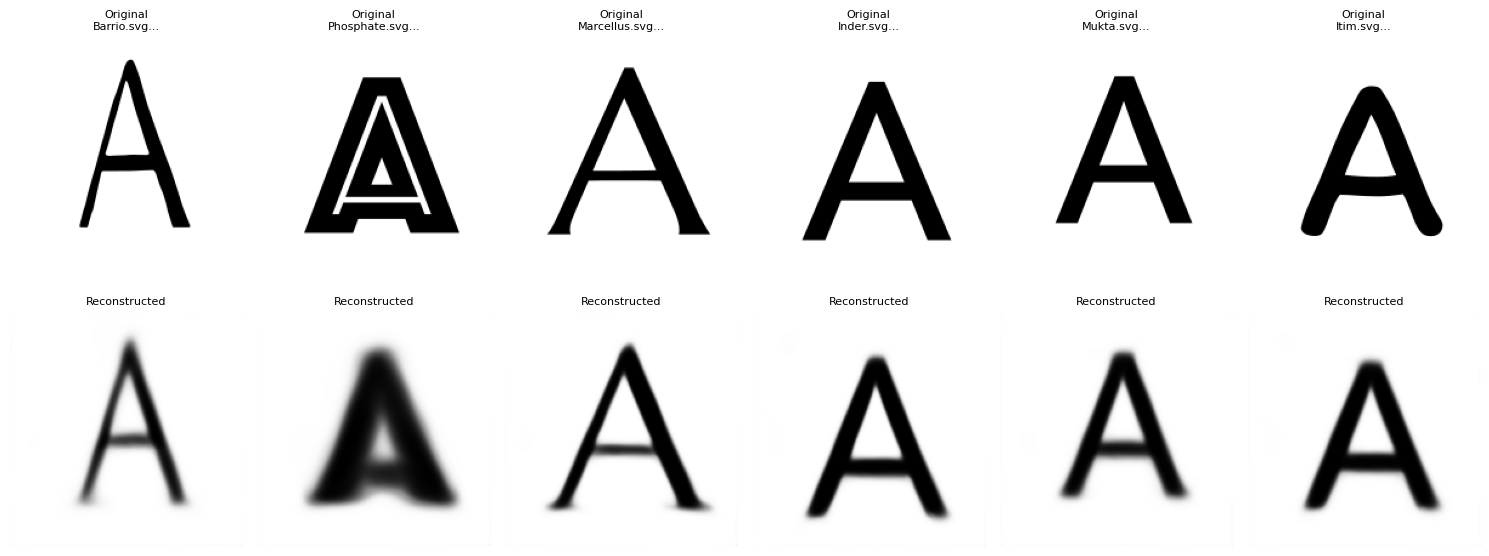

In [ ]:
SVG_FOLDER =  "/content/figma-salu-v2"  # UPDATE THIS
IMAGE_SIZE = 192
EMBEDDING_DIM = 256
BATCH_SIZE = 24  # Increased from 4
EPOCHS = 30   # Reduced from 250
USE_CONTRASTIVE = True  # Set to False for pure autoencoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

clean_dataset = SVGFontDataset(SVG_FOLDER, IMAGE_SIZE, transform=None)
clean_dataloader = DataLoader(clean_dataset, batch_size=BATCH_SIZE, shuffle=True)
visualize_reconstructions(model, clean_dataloader, device)

In [ ]:
def quick_train(svg_folder_path, use_contrastive=False):
    """Quick training with stable settings"""
    print("🚀 Quick Font Training")
    print("="*40)

    # Simple, stable configuration
    IMAGE_SIZE = 256
    BATCH_SIZE = 16
    EPOCHS = 2 # 100

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Dataset
    dataset = SVGFontDataset(svg_folder_path, IMAGE_SIZE, transform=create_augmentation_transforms())
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    # Model
    model = FontAutoencoder(input_size=IMAGE_SIZE, embedding_dim=256)

    # Initialize weights
    def init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight, gain=0.02)  # Small gain for stability
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    model.apply(init_weights)

    trainer = SimpleFontTrainer(model, device)

    print(f"Dataset: {len(dataset)} fonts")
    print(f"Contrastive: {use_contrastive}")

    # Train
    trainer.train(dataloader, epochs=EPOCHS, use_contrastive=use_contrastive)

    # Extract embeddings
    clean_dataset = SVGFontDataset(svg_folder_path, IMAGE_SIZE, transform=None)
    print(f'clean_dataset = {clean_dataset}')
    clean_dataloader = DataLoader(clean_dataset, batch_size=BATCH_SIZE, shuffle=False)
    print(f'clean_dataloader = {clean_dataloader}')
    embeddings, filenames = extract_embeddings(model, clean_dataloader, device)
    print(f'embeddings = {embeddings}, filenames = {filenames}')

    # Save
    with open('font_embeddings_simple.pkl', 'wb') as f:
        pickle.dump({
            'embeddings': embeddings,
            'filenames': filenames,
            'metadata': {'model_type': 'simple_autoencoder'}
        }, f)

    print("✅ Training completed!")
    return model, embeddings, filenames


In [ ]:
 # UPDATE THIS PATH
SVG_FOLDER = "/content/figma-salu-v2"

print("Starting font embedding training...")
print("Choose training mode:")
print("1. Pure autoencoder (more stable)")
print("2. With contrastive learning (better embeddings)")

# For initial testing, use pure autoencoder
try:
    # Start with simple autoencoder
    # COMMENTED
    # model, embeddings, filenames = quick_train(SVG_FOLDER, use_contrastive=False)

    print(f"\nSuccess! Embedding shape: {embeddings.shape}")
    print("Next: Use visualization code to see 3D embeddings")

except Exception as e:
    print(f"Error: {e}")
    # print("Try reducing batch size or image size")

Starting font embedding training...
Choose training mode:
1. Pure autoencoder (more stable)
2. With contrastive learning (better embeddings)

Success! Embedding shape: (2143, 256)
Next: Use visualization code to see 3D embeddings


# Visualisation

In [ ]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pickle
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [ ]:
!pip install umap-learn --quiet

In [ ]:
import umap

In [ ]:
UMAP_AVAILABLE = True

In [ ]:
class FontEmbedding3DVisualizer:
    def __init__(self, embeddings_path):
        """Load and prepare font embeddings for visualization"""
        with open(embeddings_path, 'rb') as f:
            data = pickle.load(f)

        self.embeddings = data['embeddings']
        self.filenames = data['filenames']
        self.metadata = data.get('metadata', {})

        # Clean font names for display
        self.font_names = [f.replace('.svg', '').replace('_', ' ') for f in self.filenames]

        print(f"Loaded {self.embeddings.shape[0]} font embeddings")
        print(f"Original embedding dimension: {self.embeddings.shape[1]}D")

        # Store different 3D projections
        self.projections_3d = {}
        self.variance_explained = {}

    def reduce_umap_3d(self, n_neighbors=15, min_dist=0.1):
        """UMAP reduction to 3D"""
        if not UMAP_AVAILABLE:
            print("❌ UMAP not available. Install with: pip install umap-learn")
            return None

        print("\n🔍 Computing UMAP...")

        # Adjust parameters for dataset size
        n_neighbors = min(n_neighbors, len(self.embeddings) // 4)

        reducer = umap.UMAP(
            n_components=3,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            spread=1.0,
            random_state=42,
            verbose=False
        )

        projection_3d = reducer.fit_transform(self.embeddings)
        self.projections_3d['UMAP'] = projection_3d

        print(f"✅ UMAP completed (neighbors={n_neighbors}, min_dist={min_dist})")
        return projection_3d


    def auto_cluster_fonts(self, projection, n_clusters=None):
        """Automatically cluster fonts"""
        if n_clusters is None:
            n_clusters = max(5, min(12, int(np.sqrt(len(projection)))))

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(projection)

        return labels, n_clusters


    def create_plotly_3d(self, method='UMAP', color_by='cluster', n_clusters=8):
            """Create interactive 3D Plotly visualization"""

            # Get or compute projection
            if method not in self.projections_3d:
                if method == 'PCA':
                    projection = self.reduce_pca_3d()
                elif method == 't-SNE':
                    projection = self.reduce_tsne_3d()
                elif method == 'UMAP':
                    projection = self.reduce_umap_3d()
                else:
                    raise ValueError(f"Unknown method: {method}")
            else:
                projection = self.projections_3d[method]

            if projection is None:
                return None

            # Create DataFrame
            df = pd.DataFrame({
                'x': projection[:, 0],
                'y': projection[:, 1],
                'z': projection[:, 2],
                'font_name': self.font_names,
                'filename': self.filenames
            })

            # Add coloring information
            if color_by == 'cluster':
                cluster_labels, n_clusters = self.auto_cluster_fonts(projection, n_clusters)
                df['category'] = [f'Cluster {i}' for i in cluster_labels]
                colors = px.colors.qualitative.Set3
            else:
                df['category'] = self.categorize_fonts_by_name()
                colors = px.colors.qualitative.Set2

            # Create 3D scatter plot
            fig = px.scatter_3d(
                df, x='x', y='y', z='z',
                color='category',
                hover_name='font_name',
                hover_data={'filename': True},
                color_discrete_sequence=colors,
                title=f'3D Font Embedding Space - {method}'
            )

            # Update traces for better visualization
            fig.update_traces(
                marker=dict(
                    size=6,
                    opacity=0.8,
                    line=dict(width=0.5, color='white')
                )
            )

            # Update layout
            fig.update_layout(
                scene=dict(
                    xaxis_title=f'{method} Component 1',
                    yaxis_title=f'{method} Component 2',
                    zaxis_title=f'{method} Component 3',
                    camera=dict(eye=dict(x=1.3, y=1.3, z=1.3)),
                    bgcolor='rgba(240,240,240,0.1)',
                    xaxis=dict(backgroundcolor='rgba(0,0,0,0)', gridcolor='lightgray'),
                    yaxis=dict(backgroundcolor='rgba(0,0,0,0)', gridcolor='lightgray'),
                    zaxis=dict(backgroundcolor='rgba(0,0,0,0)', gridcolor='lightgray')
                ),
                width=1000,
                height=700,
                margin=dict(l=0, r=0, b=0, t=50),
                font=dict(size=12)
        )

    def create_best_visualization(self):
        """Create the best single visualization (UMAP if available, else t-SNE)"""
        if UMAP_AVAILABLE:
            method = 'UMAP'
            projection = self.reduce_umap_3d(n_neighbors=12, min_dist=0.05)

        if projection is None:
            print("❌ Could not compute projection")
            return None

        # Create enhanced visualization
        cluster_labels, n_clusters = self.auto_cluster_fonts(projection)

        # Create DataFrame with all info
        df = pd.DataFrame({
            'x': projection[:, 0],
            'y': projection[:, 1],
            'z': projection[:, 2],
            'font_name': self.font_names,
            'cluster': '1' # [f'Group {i+1}' for i in cluster_labels],
            # 'font_type': self.categorize_fonts_by_name()
        })

        # Create the plot
        fig = px.scatter_3d(
            df, x='x', y='y', z='z',
            color='cluster',
            hover_name='font_name',
            # hover_data={'font_type': True},
            title=f'Font Similarity Space - {method} Projection',
            color_discrete_sequence=px.colors.qualitative.Set3
        )

        # Enhanced styling
        fig.update_traces(
            marker=dict(
                size=7,
                opacity=0.8,
                line=dict(width=1, color='rgba(255,255,255,0.8)')
            )
        )

        # Beautiful layout
        fig.update_layout(
            scene=dict(
                xaxis_title=f'{method} Dimension 1',
                yaxis_title=f'{method} Dimension 2',
                zaxis_title=f'{method} Dimension 3',
                camera=dict(eye=dict(x=1.4, y=1.4, z=1.4)),
                bgcolor='rgba(248,249,250,0.8)',
                xaxis=dict(
                    backgroundcolor='rgba(0,0,0,0)',
                    gridcolor='rgba(128,128,128,0.3)',
                    showbackground=True,
                    # backgroundcolor='rgba(230,230,230,0.3)'
                ),
                yaxis=dict(
                    backgroundcolor='rgba(0,0,0,0)',
                    gridcolor='rgba(128,128,128,0.3)',
                    showbackground=True,
                    # backgroundcolor='rgba(230,230,230,0.3)'
                ),
                zaxis=dict(
                    backgroundcolor='rgba(0,0,0,0)',
                    gridcolor='rgba(128,128,128,0.3)',
                    showbackground=True,
                    # backgroundcolor='rgba(230,230,230,0.3)'
                )
            ),
            width=1100,
            height=800,
            margin=dict(l=0, r=0, b=0, t=60),
            font=dict(size=12),
            legend=dict(
                yanchor="top",
                y=0.99,
                xanchor="left",
                x=0.01,
                bgcolor='rgba(255,255,255,0.8)',
                bordercolor='gray',
                borderwidth=1
            )
        )

        return fig, df


# Main visualization functions
def visualize_embeddings(embeddings_path, method='best'):
    """Main function to visualize font embeddings"""
    print("🎨 Font Embedding 3D Visualization")
    print("="*50)

    # Load visualizer
    visualizer = FontEmbedding3DVisualizer(embeddings_path)
    # visualizer.print_analysis_summary()

    if method == 'best':
        # Use best available method
        fig, df = visualizer.create_best_visualization()
    elif method == 'comparison':
        # Compare multiple methods
        fig, df = visualizer.create_method_comparison()
    elif method == 'pca_detailed':
        # Detailed PCA analysis
        fig, df = visualizer.create_pca_detailed_analysis()
    else:
        # Specific method
        fig, df = visualizer.create_plotly_3d(method=method)

    if fig:
        fig.show()

        # Save as HTML
        filename = f'font_embeddings_{method}.html'
        fig.write_html(filename)
        print(f"\n✅ Saved interactive plot: {filename}")

    return visualizer, df

# def quick_3d_view(embeddings_path):
#     """Quick 3D visualization with best method"""
#     visualizer = FontEmbedding3DVisualizer(embeddings_path)

#     # Use UMAP if available, else PCA
#     if UMAP_AVAILABLE:
#         print("Using UMAP for visualization...")
#         fig, df = visualizer.create_plotly_3d(method='UMAP', color_by='cluster')
#     else:
#         print("Using PCA for visualization...")
#         fig, df = visualizer.create_plotly_3d(method='PCA', color_by='cluster')

#     fig.show()
#     return visualizer

In [ ]:
# Quick view
# visualizer = quick_3d_view('font_embeddings_simple.pkl')

In [ ]:
# Best visualization
# visualizer = visualize_embeddings('font_embeddings_simple.pkl', method='best')
visualizer, df = visualize_embeddings('font_embeddings.pkl', method='best')

🎨 Font Embedding 3D Visualization
Loaded 2143 font embeddings
Original embedding dimension: 256D

🔍 Computing UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



✅ UMAP completed (neighbors=12, min_dist=0.05)



✅ Saved interactive plot: font_embeddings_best.html


In [ ]:
df

,x,y,z,font_name,cluster
0,-2.109122,-2.578775,5.947638,----,1
1,-2.116348,-2.570118,5.934125,---,1
2,1.861024,0.722492,7.367732,ABeeZee,1
3,-1.771937,1.495465,7.465214,ADLaM-Display,1
4,2.975074,-0.723201,8.740972,AR-One-Sans,1
...,...,...,...,...,...
2138,0.318248,-1.894829,5.849399,jsMath-cmex10,1
2139,-0.921853,-0.394813,4.492273,jsMath-cmmi10,1
2140,1.959114,-0.731841,3.921875,jsMath-cmr10,1
2141,1.904776,0.495376,1.912456,jsMath-cmsy10,1


In [ ]:
df['font_name'] = df['font_name'].str.replace(' ', '-')

In [ ]:
# drop rows where font_name is "----" or "---"
df.drop(df[df['font_name'] == '----'].index, inplace=True)
df.drop(df[df['font_name'] == '---'].index, inplace=True)

df = df.reset_index(drop=True)

In [ ]:
df.head()

,x,y,z,font_name,cluster
0,1.861024,0.722492,7.367732,ABeeZee,1
1,-1.771937,1.495465,7.465214,ADLaM-Display,1
2,2.975074,-0.723201,8.740972,AR-One-Sans,1
3,1.007253,-1.854505,6.634695,Abel,1
4,-1.713493,-2.050250,6.374938,Abhaya-Libre-ExtraBold,1


## Check closest few

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import zipfile

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pickle
# from cairosvg import svg2png
from io import BytesIO

In [ ]:
with open("/content/font_embeddings.pkl", 'rb') as f:
    embeddings_data = pickle.load(f)

In [ ]:
embeddings_data.keys()

dict_keys(['embeddings', 'filenames', 'metadata'])

In [ ]:
print(f' earlier embeddings shape = {embeddings_data['embeddings'].shape}')
embeddings_data['embeddings'] = embeddings_data['embeddings'][2:]
print(f' now embeddings shape = {embeddings_data['embeddings'].shape}')

In [ ]:
embeddings_data['embeddings'].shape

(2141, 256)

In [ ]:
print(f' earlier filenames shape = {embeddings_data['filenames'].shape}')
embeddings_data['filenames'] = embeddings_data['filenames'][2:]
print(f' earlier filenames shape = {embeddings_data['filenames'].shape}')

In [ ]:
embeddings_data['metadata']

{'embedding_dim': 256,
 'image_size': 192,
 'num_fonts': 2143,
 'contrastive': True}

In [ ]:
def analyze_embeddings(embeddings, filenames, top_k=3):
    """Analyze embedding similarities"""
    print("\nFont Similarity Analysis:")
    print("=" * 50)

    similarity_matrix = cosine_similarity(embeddings)

    big_list = []

    for i, filename in enumerate(filenames):

        similarities = similarity_matrix[i]
        top_indices = np.argsort(similarities)[-top_k-1:-1][::-1]

        # print(f"\nFont: {filename}")
        # print("Most similar:")

        top_matches = []
        for j, idx in enumerate(top_indices):
            if idx != i:

                similar_font_name = filenames[idx].replace(" ", "-")
                similiar_font_similarity_score = round(float(similarities[idx]), 3)
                # print(f"  {j+1}. {filenames[idx]} ({similarities[idx]:.3f})")
                # print(f"  {similar_font_name} --  ({similiar_font_similarity_score})")

                top_matches.append({similar_font_name : similiar_font_similarity_score })

        big_list.append({filename: top_matches})

    return big_list




In [ ]:
big_list = analyze_embeddings(embeddings_data['embeddings'], embeddings_data['filenames'])


Font Similarity Analysis:


In [ ]:
len(big_list)

2141

In [ ]:
1

1

In [ ]:
big_list[:2]

[{'ABeeZee.svg': [{'Numans.svg': 0.963},
   {'Varela-Round.svg': 0.905},
   {'Hei.svg': 0.864}]},
 {'ADLaM-Display.svg': [{'Ramabhadra.svg': 0.826},
   {'Tilt-Warp.svg': 0.808},
   {'Bagel-Fat-One.svg': 0.771}]}]

## Convert to json as expected

In [ ]:
# --- Convert big_list into mapping font_name -> list of similar fonts ---
similar_fonts_map = {}
for item in big_list:
    for font_svg, similars in item.items():
        font = font_svg.replace(".svg", "")
        similar_fonts = [list(d.keys())[0].replace(".svg", "") for d in similars]
        similar_fonts_map[font] = similar_fonts

# similar_fonts_map

In [ ]:
1

1

In [ ]:
x_mean = df['x'].mean()
y_mean = df['y'].mean()
z_mean = df['z'].mean()
x_mean, y_mean, z_mean

(np.float32(0.96974814), np.float32(-0.33960152), np.float32(6.266664))

In [ ]:
import json

In [ ]:
# --- Build final rows ---
rows = []

# for i, row in df.iterrows():
for idx, x,y,z, font_name in zip(df.index, df['x'], df['y'], df['z'], df['font_name']):
    # font = row["font_name"]
    font = font_name

    xx = float(x - x_mean)
    yy = float(y - y_mean)
    zz = float(z - z_mean)



    key = f"font:{font}"
    value = {
        "id": f"font-{idx}",   # simple id
        "category": "analysing",  # placeholder for now
        "fontName": font,
        "position": {
            "x": xx*12, # row["x"],
            "y": yy*12, # row["y"],
            "z": zz*12, # row["z"]
        },
        "similarFonts": similar_fonts_map.get(font, [])
    }

    rows.append({"key": key, "value": json.dumps(value)})

# --- Create final DataFrame ---
final_df = pd.DataFrame(rows)

# --- Save to CSV ---
final_df.to_csv("fonts_output_fontify_v8.csv", index=False)

print(final_df.head())


                           key  \
0                 font:ABeeZee   
1           font:ADLaM-Display   
2             font:AR-One-Sans   
3                    font:Abel   
4  font:Abhaya-Libre-ExtraBold   

                                               value  
0  {"id": "font-0", "category": "analysing", "fon...  
1  {"id": "font-1", "category": "analysing", "fon...  
2  {"id": "font-2", "category": "analysing", "fon...  
3  {"id": "font-3", "category": "analysing", "fon...  
4  {"id": "font-4", "category": "analysing", "fon...  
